c:\Users\HP\OneDrive\Desktop\LangGraph-Tutorial\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


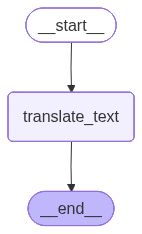

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

#creating subgraph...

class SubState(TypedDict):

    input_text: str
    translated_text: str


subgraph_llm = ChatGroq(model="llama-3.3-70b-versatile")

def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}


subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()
subgraph


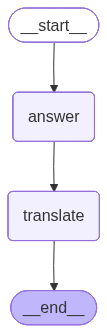

In [2]:

#creating parent state....

class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

parent_llm = ChatGroq(model="llama-3.1-8b-instant")

def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}


def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}



parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)


graph = parent_builder.compile()

graph




In [3]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at an atomic and subatomic level. At these scales, the classical laws of physics no longer apply, and strange, seemingly random phenomena occur.\n\nIn classical physics, the position, momentum, and energy of an object are well-defined and can be measured precisely. However, in quantum physics, these properties become uncertain and are described using probability distributions.\n\nSome key principles of quantum physics include:\n\n1. **Wave-particle duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior.\n2. **Uncertainty principle**: It is impossible to know certain properties, like position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously.\n4. **Entanglement**: Quantum objects can